# Versión 2.5 — Panel de señales configurable multimercado

## Diferencias respecto a la versión 2.4

- La V2.4 gestiona una posición real configurada manualmente. La V2.5 no consulta la cuenta ni necesita saber qué operaciones ejecutaste.
- La V2.5 reconstruye tres estrategias virtuales independientes: LONG RSI+Bollinger, SHORT RSI y SHORT Ruptura. Una entrada LONG nunca bloquea una entrada SHORT, y los dos sistemas SHORT tampoco se bloquean entre sí.
- Cada sistema mantiene como máximo una operación virtual abierta: mientras esa operación siga abierta no duplica nuevas entradas del mismo sistema, pero los otros sistemas continúan evaluándose.
- Cada estrategia solo genera SALIR si antes generó su propia entrada virtual. Cada entrada queda enlazada con su salida, sus fechas y los valores que activaron ambas señales.
- Las operaciones y marcas relacionadas con los últimos 30 días permanecen en el informe y en los gráficos.
- El precio virtual de entrada es el cierre que dispara la señal; las indicaciones siguen siendo informativas para la próxima apertura.

In [1]:
# ========================= CONFIGURACIÓN V2.5 =========================
ACTIVOS = [
    'META',
    #'SHOP',#
    'AAPL',
    # 'NVDA',
    # 'MSFT',
    # 'AMZN',
]

# None/'HOY' analiza el último cierre disponible.
FECHA_FIN = None
# FECHA_FIN = '2026-08-26'
AJUSTAR_DIVIDENDOS = True

# LONG: todos los criterios descomentados deben cumplirse a la vez (AND).
# Comenta o descomenta una línea para quitar o añadir ese criterio.
CRITERIOS_LONG = [
    'RSI_SOBREVENTA',
    'BOLLINGER_INFERIOR',
]
# La salida LONG conserva la V2.4: basta un criterio activo (OR).
CRITERIOS_SALIDA_LONG = [
    'RSI_RECUPERADO',
    'BOLLINGER_MEDIA',
    'STOP_PROTECCION',
]

# SHORT: basta con que se cumpla uno de los sistemas activos (OR).
# Se conserva la V2.4: RSI > 70, o RUPTURA de precio + volumen.
SISTEMAS_SHORT_ACTIVOS = [
    'RSI',
    'RUPTURA',
]

# Dentro de cada sistema SHORT, los criterios activos se combinan con AND.
CRITERIOS_SHORT_RSI = [
    'RSI_SOBRECOMPRA',
]
CRITERIOS_SHORT_RUPTURA = [
    'RUPTURA_MINIMO',
    'VOLUMEN_RUPTURA',
]

# Salidas SHORT por sistema. Dentro de cada lista basta una condición (OR).
CRITERIOS_SALIDA_SHORT_RSI = [
    'RSI_NORMALIZADO',
    'STOP_PROTECCION',
]
CRITERIOS_SALIDA_SHORT_RUPTURA = [
    'DOS_CIERRES_EMA',
    'RSI_FIN_RUPTURA',
    'MAX_SESIONES',
    'TRAILING_ATR',
]

# Periodos y umbrales editables. Los valores iniciales reproducen V2.4.
RSI_PERIODO = 14
UMBRAL_RSI_LONG = 30
BOLLINGER_PERIODO = 20
BOLLINGER_DESVIACIONES = 2.0
UMBRAL_SALIDA_LONG_RSI = 65
UMBRAL_RSI_SHORT = 70
UMBRAL_SALIDA_SHORT_RSI = 50
UMBRAL_FIN_RUPTURA_RSI = 55
PERIODO_RUPTURA = 20
MULTIPLICADOR_VOLUMEN = 1.00
EMA_SHORT_PERIODO = 10
ATR_PERIODO = 14
STOP_LONG = 0.07
STOP_SHORT = 0.07
RUPTURA_ATR = 2.0
RUPTURA_MAX_SESIONES = 20
VENTANA_SENALES_DIAS = 30
# ======================================================================

## Calendario dinámico de eventos

Mantiene los bloques verticales por valor de la V2.4 y comparte las fechas de resultados con los gráficos.

In [2]:
from calendario_eventos_v2_4 import generar_calendario_eventos

EVENTOS_CALENDARIO_MANUALES = globals().get('EVENTOS_CALENDARIO_MANUALES', {})
_calendario = generar_calendario_eventos(
    ACTIVOS, eventos_manuales=EVENTOS_CALENDARIO_MANUALES, mostrar=True
)
FECHAS_RESULTADOS_GRAFICOS = _calendario['FECHAS_RESULTADOS_GRAFICOS']
DATOS_ALERTA_RESULTADOS = _calendario['DATOS_ALERTA_RESULTADOS']
FILAS_CALENDARIO_EVENTOS = _calendario['FILAS_CALENDARIO_EVENTOS']

Fecha prevista,Tipo,Evento próximo,Precisión,Fuente
08/09/2026,Juicio / procedimiento regulatorio,"El juicio en el caso del Fiscal General de Nuevo México, que se ha ampliado para incluir varias reclamaciones relacionadas con cuestiones de moderación de contenido, está programado para comenzar el 8 de septiembre de 2026",Exacta — último informe SEC; confirmar posibles cambios,Fuente
28/10/2026,Juicio / procedimiento regulatorio,Las próximas dos pruebas de referencia para usuarios están programadas para comenzar el 28 de octubre de 2026,Exacta — último informe SEC; confirmar posibles cambios,Fuente
28/10/2026,Presentación de resultados,Próxima presentación de resultados.,Aproximada,Fuente
Fecha del evento,Tipo,Resumen del evento,Impacto bursátil,Fuentes
29/07/2026,Presentación de resultados,Evento: Presentación de resultados trimestrales.Comunicado: Meta presenta los resultados del segundo trimestre de 2026Reuters: El flujo de caja de Meta se desploma a medida que Zuckerberg duplica el gasto en IAWSJ: La acción de Meta cae un 10 % por mayores costes de IA y una previsión incumplida,↓ -7.95 %,Meta Investor Relations · Reuters · WSJ
01/07/2026,Movimiento diario superior al 7 %,CNBC: El plan de Meta para lanzar un negocio en la nube alivia la mayor sobrecarga en las accionesBarron's: Por qué el paso de Meta a la nube es un gran problema y malas noticias para CoreWeave y NebiusYahoo Finance: ¿Por qué las (META) acciones de Meta se disparan hoy?,↑ +8.81 %,CNBC · Barron's · Yahoo Finance
29/04/2026,Presentación de resultados,Evento: Presentación de resultados trimestrales.Comunicado: Meta presenta los resultados del primer trimestre de 2026Reuters: Las acciones de Meta caen por las preocupaciones sobre el gasto en IA y el escrutinio legalAP News: Meta supera las expectativas de ingresos y aumenta la previsión de gasto de capital para 2026,↓ -8.55 %,PR Newswire · Reuters · AP News
26/03/2026,Movimiento diario superior al 7 %,"Reuters: Las acciones de Meta caen ante los temores de que los veredictos de EE. UU. abran la puerta a una avalanchaBarron's: Meta, Google Stock Drop. Se enfrentan a un gran momento tabacalero.Yahoo Finance: La acción de Meta se sumergen en territorio sobrevendido a medida que las Meta Plataformas pierden en un ensayo clave de adicción a las redes sociales",↓ -7.96 %,Reuters · Barron's · Yahoo Finance
Fecha prevista,Tipo,Evento próximo,Precisión,Fuente
29/10/2026,Presentación de resultados,Próxima presentación de resultados.,Aproximada,Fuente


Informe V2.4 guardado en: C:\Users\carlos.jimenez\Scripts_Bolsa_GitHub\salida_operativa\calendario_resultados\informe_resultados.html


## Panel de disparadores LONG y SHORT

Cada valor muestra primero LONG y justo debajo SHORT. Todos los parámetros aparecen siempre con sus valores actuales. Las entradas se activan en verde con **ENTRAR** y las salidas en rojo con **SALIR**. Debajo figura el historial de activaciones de 30 días, que también se marca en los gráficos.

PANEL DE SEÑALES V2.5 — cierre 2026-08-28



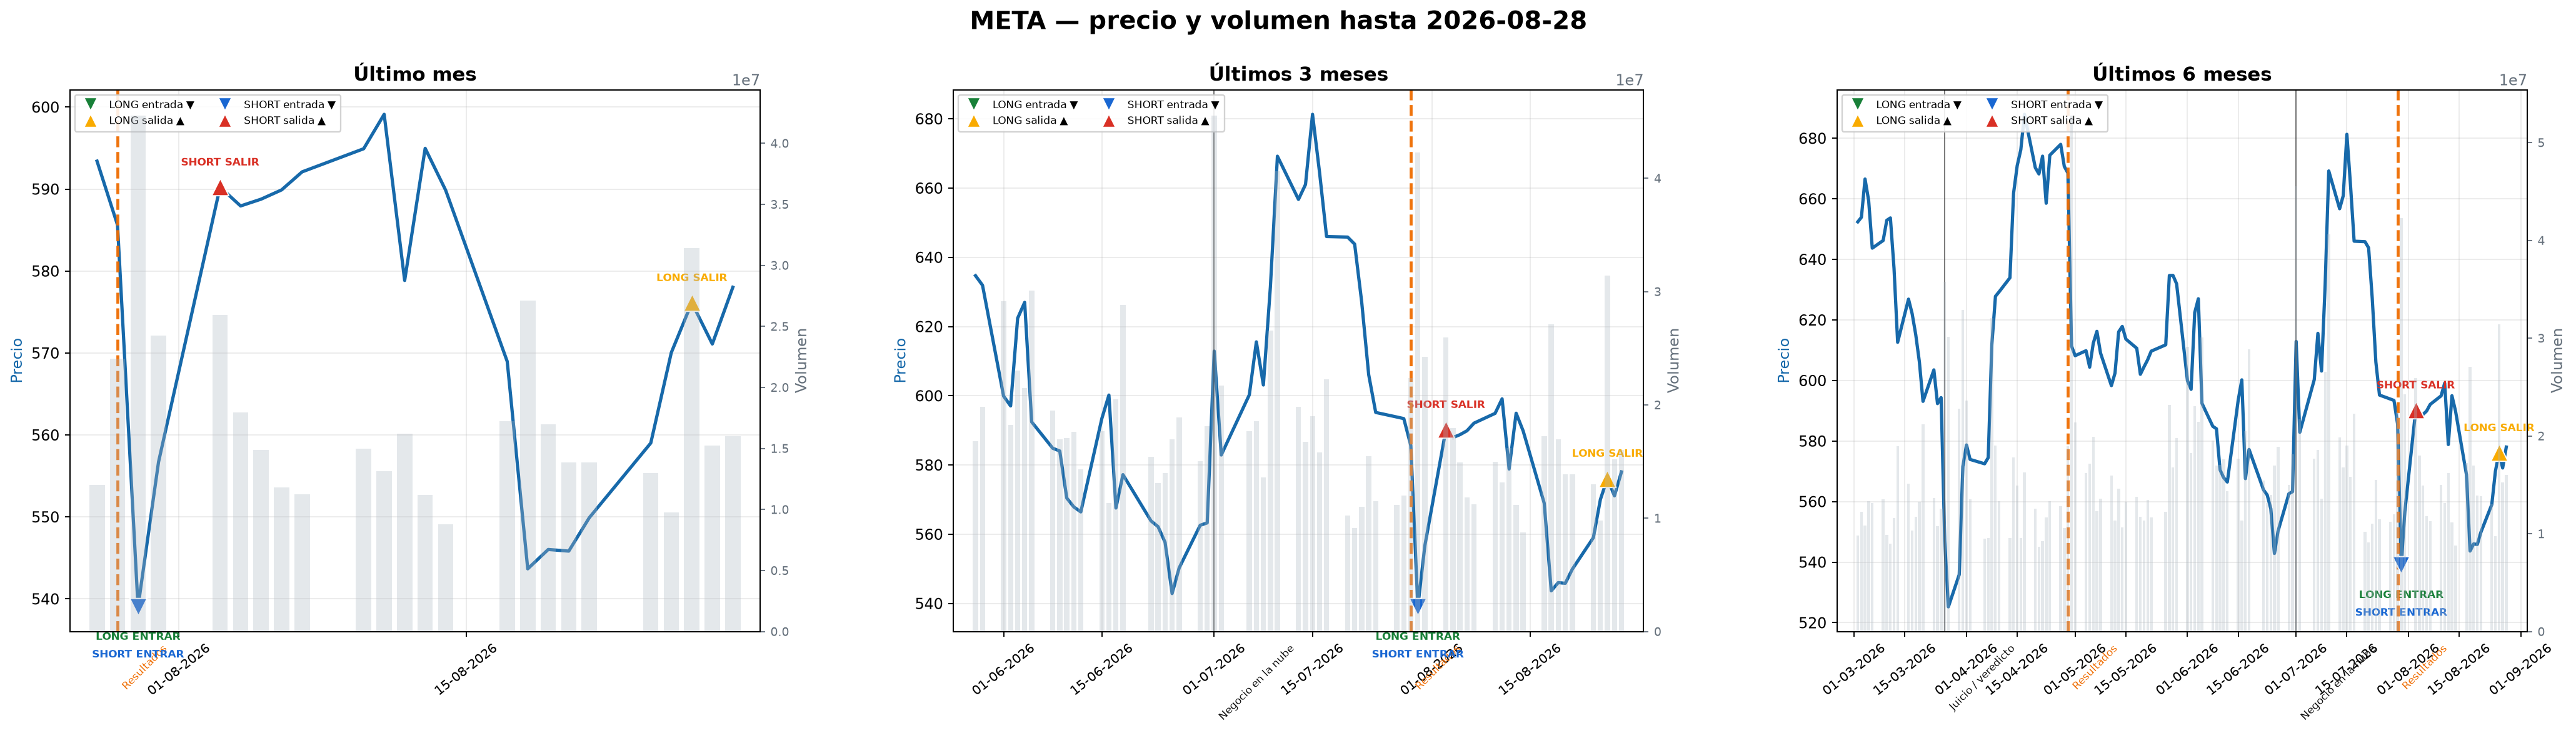

Lado,Sistema,Entrada virtual,Valores de entrada,Salida virtual,Valores de salida
LONG,RSI + BOLLINGER,▼ ENTRAR 30/07/2026 a 539.03,"✓ RSI 14 = 13.7 < 30; ✓ cierre 539.03 ≤ banda inferior 549.26 (20, 2σ)",▲ SALIR 26/08/2026 a 576.14Activó: Bollinger,✗ RSI 14 = 44.7 ≥ 65; ✓ cierre 576.14 ≥ banda media 573.10 (20); ✗ cierre 576.14 ≤ stop 501.30
SHORT,RUPTURA,▼ ENTRAR 30/07/2026 a 539.03,"✓ cierre 539.03 < mínimo previo 20 = 577.07; ✓ volumen 42,271,500 > media 20 × 1 = 19,045,385",▲ SALIR 03/08/2026 a 590.24Activó: Stop/trailing ATR,✗ dos cierres sobre EMA 10; EMA actual = 590.06; ✗ RSI 14 = 33.4 > 55; ✗ 3 sesiones desde la entrada ≥ 20; ✓ cierre 590.24 ≥ stop/trailing 574.85; ATR 14 = 26.30



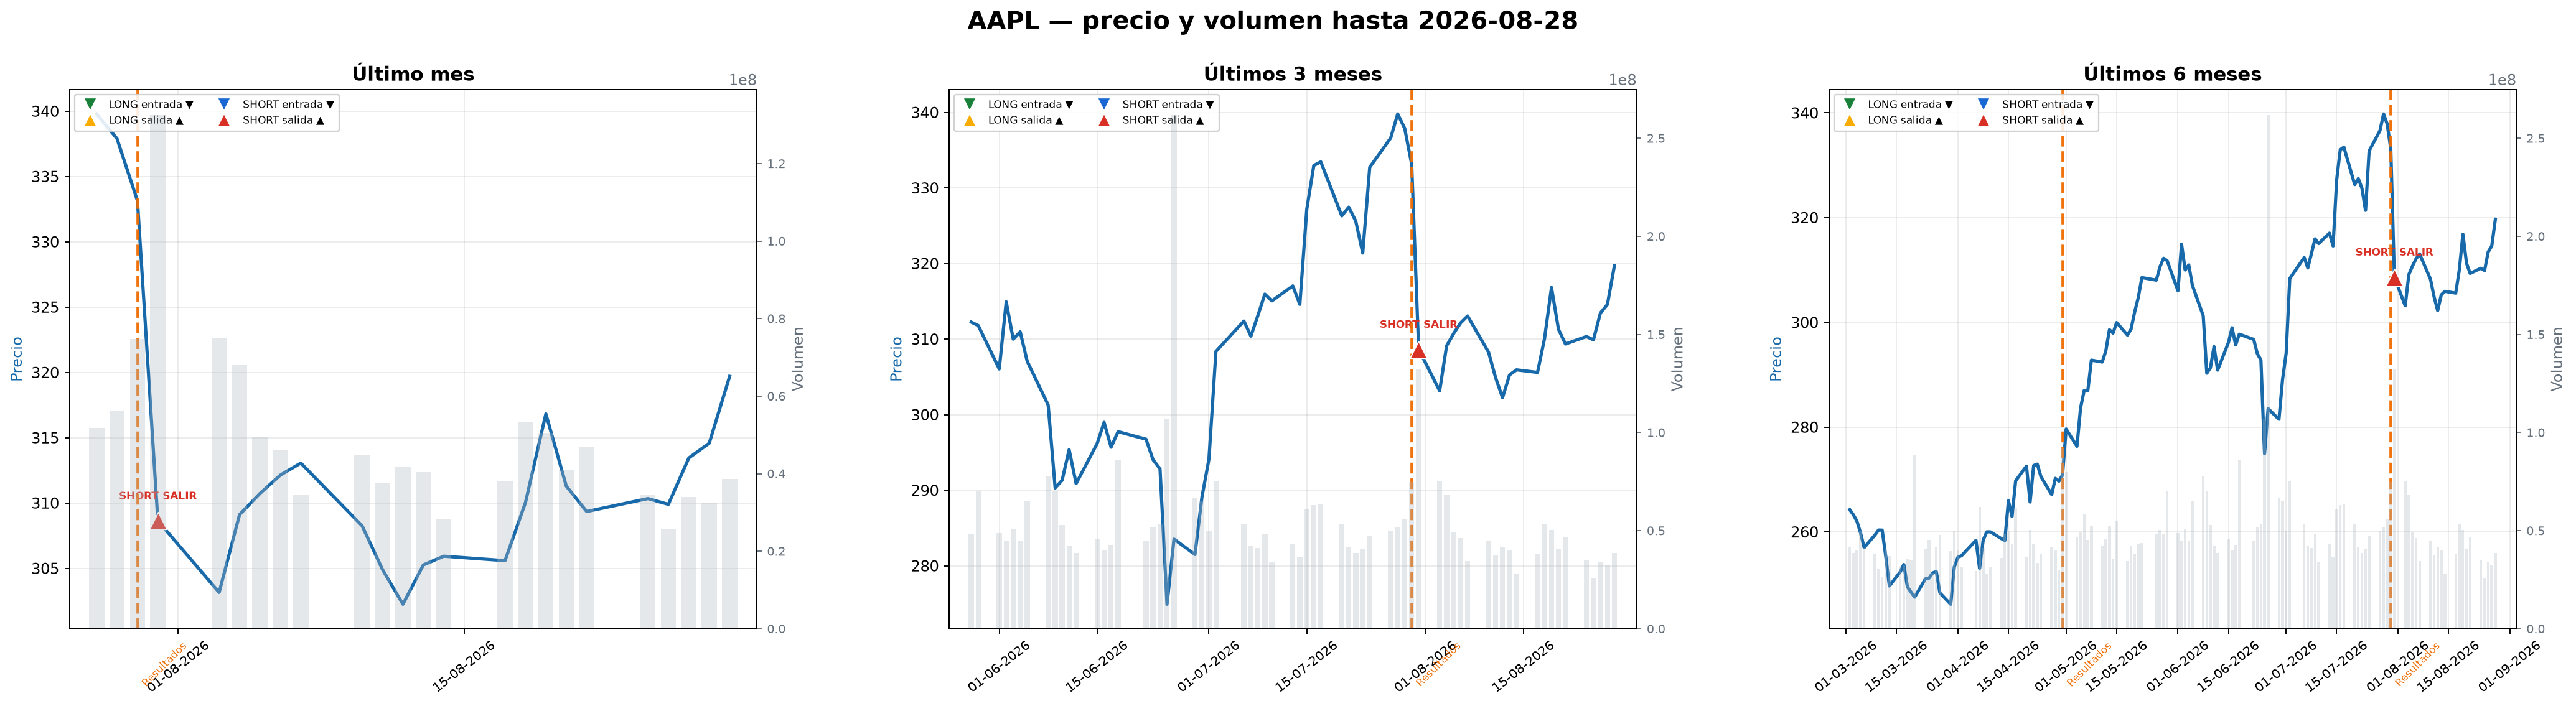

Lado,Sistema,Entrada virtual,Valores de entrada,Salida virtual,Valores de salida
SHORT,RSI,▼ ENTRAR 15/07/2026 a 327.22,✓ RSI 14 = 70.2 > 70,▲ SALIR 31/07/2026 a 308.64Activó: RSI normalizado,✓ RSI 14 = 45.1 < 50; ✗ cierre 308.64 ≥ stop 350.12


Resumen V2.5 guardado en: C:\Users\carlos.jimenez\Scripts_Bolsa_GitHub\salida_operativa\resumen_senales_v2_5.html


In [3]:
import importlib
import panel_senales_v2_5
importlib.reload(panel_senales_v2_5)
from panel_senales_v2_5 import generar_panel_senales

resultado_v2_5 = generar_panel_senales(
    ACTIVOS,
    fecha_fin=FECHA_FIN,
    ajustar_dividendos=AJUSTAR_DIVIDENDOS,
    criterios_long=CRITERIOS_LONG,
    criterios_salida_long=CRITERIOS_SALIDA_LONG,
    sistemas_short=SISTEMAS_SHORT_ACTIVOS,
    criterios_short_rsi=CRITERIOS_SHORT_RSI,
    criterios_short_ruptura=CRITERIOS_SHORT_RUPTURA,
    criterios_salida_short_rsi=CRITERIOS_SALIDA_SHORT_RSI,
    criterios_salida_short_ruptura=CRITERIOS_SALIDA_SHORT_RUPTURA,
    rsi_periodo=RSI_PERIODO,
    umbral_rsi_long=UMBRAL_RSI_LONG,
    bollinger_periodo=BOLLINGER_PERIODO,
    bollinger_desviaciones=BOLLINGER_DESVIACIONES,
    umbral_salida_long_rsi=UMBRAL_SALIDA_LONG_RSI,
    umbral_rsi_short=UMBRAL_RSI_SHORT,
    umbral_salida_short_rsi=UMBRAL_SALIDA_SHORT_RSI,
    umbral_fin_ruptura_rsi=UMBRAL_FIN_RUPTURA_RSI,
    periodo_ruptura=PERIODO_RUPTURA,
    multiplicador_volumen=MULTIPLICADOR_VOLUMEN,
    ema_short_periodo=EMA_SHORT_PERIODO,
    atr_periodo=ATR_PERIODO,
    stop_long=STOP_LONG,
    stop_short=STOP_SHORT,
    ruptura_atr=RUPTURA_ATR,
    ruptura_max_sesiones=RUPTURA_MAX_SESIONES,
    ventana_senales_dias=VENTANA_SENALES_DIAS,
    fechas_resultados=FECHAS_RESULTADOS_GRAFICOS,
    datos_alerta_resultados=DATOS_ALERTA_RESULTADOS,
    filas_calendario_eventos=FILAS_CALENDARIO_EVENTOS,
    mostrar=True,
)
SENALES_V2_5 = resultado_v2_5['senales']
HISTORIAL_SENALES_V2_5 = resultado_v2_5['historial_senales']
OPERACIONES_VIRTUALES_V2_5 = resultado_v2_5['operaciones_virtuales']
ARCHIVO_RESUMEN_V2_5 = resultado_v2_5['archivo_html']

## Uso diario

1. Ajusta los criterios activos comentando o descomentando líneas en la configuración.
2. Modifica periodos o umbrales si quieres probar otra variante.
3. Ejecuta todas las celdas después del cierre estadounidense.
4. `ENTRAR` verde abre una operación virtual del sistema correspondiente; `SALIR` rojo solo puede aparecer después de esa entrada.
5. Revisa la tabla para ver cada entrada enlazada con su salida y los valores que activaron ambas.
6. Las marcas del gráfico conservan las entradas y salidas relacionadas con los 30 días anteriores.
7. LONG, SHORT RSI y SHORT Ruptura son independientes de la cuenta real y entre sí.

El notebook no transmite órdenes ni comprueba posiciones, stops, disponibilidad o coste de préstamo para operar en corto.